# Baseline Modelling: Human Movement

This notebook evaluates whether the extracted pose-based features can distinguish between the five instructed movement classes.

Frame-level observations are aggregated into trial-level features, and evaluation uses leave-one-participant-out splitting.

The notebook first establishes a baseline using Logistic Regression and a dummy classifier. A feature ablation then tests whether a simpler representation using fewer summary statistics provides comparable or improved generalisation.

The results provide the reference point for the subsequent personalised modelling experiments.

## Experimental Setup

The dataset contains:

- 2 participants
- 2 sessions per participant
- 100 trials
- 5 movement classes
- 20 trials per movement class
- approximately 4 seconds per trial
- approximately 56 observations per trial

The five movement classes are:

- `neutral`
- `raise_arms`
- `lean_left`
- `lean_right`
- `lean_forward`

Each trial is represented by summary statistics calculated from its frame-level movement features.

Evaluation uses leave-one-participant-out splitting:

- train on one participant and test on the other
- repeat with the participants exchanged

This ensures that the test participant is completely unseen during model training.

In [38]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [39]:
DATA_DIR = Path("../data/movement")

IDENTIFIER_COLUMNS = [
    "participant_id",
    "session_id",
    "trial_id",
    "movement_label",
]

FEATURE_COLUMNS = [
    "shoulder_width",
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "movement_speed",
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

TARGET_COLUMN = "movement_label"

GROUP_COLUMNS = [
    "participant_id",
    "session_id",
    "trial_id",
    "movement_label",
]

AGGREGATION_FUNCTIONS = [
    "mean",
    "std",
    "min",
    "max",
]

In [40]:
# Load dataset

files = sorted(DATA_DIR.glob("P*_S*.csv"))

if not files:
    raise FileNotFoundError(
        f"No participant/session CSV files found in {DATA_DIR.resolve()}"
    )

frames = [pd.read_csv(file) for file in files]

df = pd.concat(
    frames,
    ignore_index=True,
)

print(f"Files loaded: {len(files)}")
print(f"Dataset shape: {df.shape}")

Files loaded: 4
Dataset shape: (5555, 14)


In [41]:
display(
    df[
        [
            "participant_id",
            "session_id",
            "trial_id",
            "movement_label",
        ]
    ].head()
)

,participant_id,session_id,trial_id,movement_label
0,P01,S01,1,neutral
1,P01,S01,1,neutral
2,P01,S01,1,neutral
3,P01,S01,1,neutral
4,P01,S01,1,neutral


In [42]:
# Trial-level representation
# Frame-level observations are aggregated into one row per trial.

trial_features = (
    df.groupby(GROUP_COLUMNS)[FEATURE_COLUMNS]
    .agg(AGGREGATION_FUNCTIONS)
)

trial_features.columns = [
    f"{feature}_{stat}"
    for feature, stat in trial_features.columns
]

trial_features = trial_features.reset_index()

print(f"Trials: {len(trial_features)}")
print(f"Trial-level features: {len(trial_features.columns)}")

display(trial_features.head())

Trials: 100
Trial-level features: 40


,participant_id,session_id,trial_id,movement_label,shoulder_width_mean,shoulder_width_std,shoulder_width_min,shoulder_width_max,head_offset_x_mean,head_offset_x_std,head_offset_x_min,head_offset_x_max,head_offset_y_mean,head_offset_y_std,head_offset_y_min,head_offset_y_max,torso_dx_mean,torso_dx_std,torso_dx_min,torso_dx_max,torso_dy_mean,torso_dy_std,torso_dy_min,torso_dy_max,movement_speed_mean,movement_speed_std,movement_speed_min,movement_speed_max,head_offset_z_mean,head_offset_z_std,head_offset_z_min,head_offset_z_max,torso_dz_mean,torso_dz_std,torso_dz_min,torso_dz_max,movement_speed_3d_mean,movement_speed_3d_std,movement_speed_3d_min,movement_speed_3d_max
0,P01,S01,1,neutral,0.333478,0.001824,0.332019,0.338862,0.027531,0.005356,0.017358,0.040083,-0.892127,0.013139,-0.910118,-0.855146,-0.000470,0.001788,-0.008693,0.002234,0.002372,0.003835,-0.001458,0.013246,0.043863,0.058488,0.0,0.250578,-0.634818,0.006986,-0.648257,-0.621308,0.000829,0.009888,-0.024675,0.040932,0.108272,0.103189,0.0,0.561603
1,P01,S01,2,neutral,0.335893,0.000788,0.334116,0.337427,0.037758,0.003797,0.029882,0.046012,-1.033394,0.012667,-1.057834,-1.009514,-0.000008,0.000514,-0.001442,0.000816,0.000202,0.001966,-0.005952,0.007358,0.021114,0.022412,0.0,0.104929,-0.535309,0.022043,-0.575978,-0.467373,0.001613,0.029885,-0.068112,0.091241,0.384039,0.378843,0.0,2.103741
2,P01,S01,3,neutral,0.333582,0.001072,0.332415,0.337141,0.029839,0.004679,0.024641,0.045967,-0.960535,0.008964,-0.983787,-0.942649,-0.000016,0.000351,-0.001334,0.000783,-0.000060,0.001102,-0.004091,0.003732,0.013270,0.013942,0.0,0.082244,-0.591936,0.005654,-0.603133,-0.578602,-0.000329,0.007374,-0.029549,0.020634,0.088512,0.085349,0.0,0.383539
3,P01,S01,4,neutral,0.335082,0.000511,0.334168,0.336226,0.041286,0.003732,0.033055,0.050552,-0.931393,0.009354,-0.950397,-0.910570,0.000078,0.000487,-0.000853,0.001733,0.000136,0.001519,-0.004978,0.004061,0.016416,0.015690,0.0,0.077571,-0.604767,0.008319,-0.624559,-0.583149,-0.000259,0.005510,-0.012487,0.010232,0.086544,0.055718,0.0,0.244262
4,P01,S01,5,neutral,0.336775,0.000574,0.336090,0.338671,0.042007,0.003948,0.033847,0.048941,-0.916819,0.009203,-0.934231,-0.895239,0.000017,0.000464,-0.001293,0.001116,0.000445,0.002508,-0.004032,0.011581,0.028936,0.028535,0.0,0.144931,-0.602010,0.006255,-0.622974,-0.591185,-0.000800,0.010731,-0.037590,0.024136,0.133506,0.117260,0.0,0.523861


In [43]:
trial_feature_columns = [
    column
    for column in trial_features.columns
    if column not in GROUP_COLUMNS
]

print(f"Rows: {len(trial_features):,}")
print(f"Modelling features: {len(trial_feature_columns)}")
print(f"Participants: {trial_features['participant_id'].nunique()}")
print(
    f"Sessions: "
    f"{len(trial_features[['participant_id', 'session_id']].drop_duplicates())}"
)
print(f"Trials: {len(trial_features)}")
print(f"Movement classes: {trial_features[TARGET_COLUMN].nunique()}")

Rows: 100
Modelling features: 36
Participants: 2
Sessions: 4
Trials: 100
Movement classes: 5


In [44]:
display(
    trial_features[TARGET_COLUMN]
    .value_counts()
    .sort_index()
)

movement_label
lean_forward    20
lean_left       20
lean_right      20
neutral         20
raise_arms      20
Name: count, dtype: int64

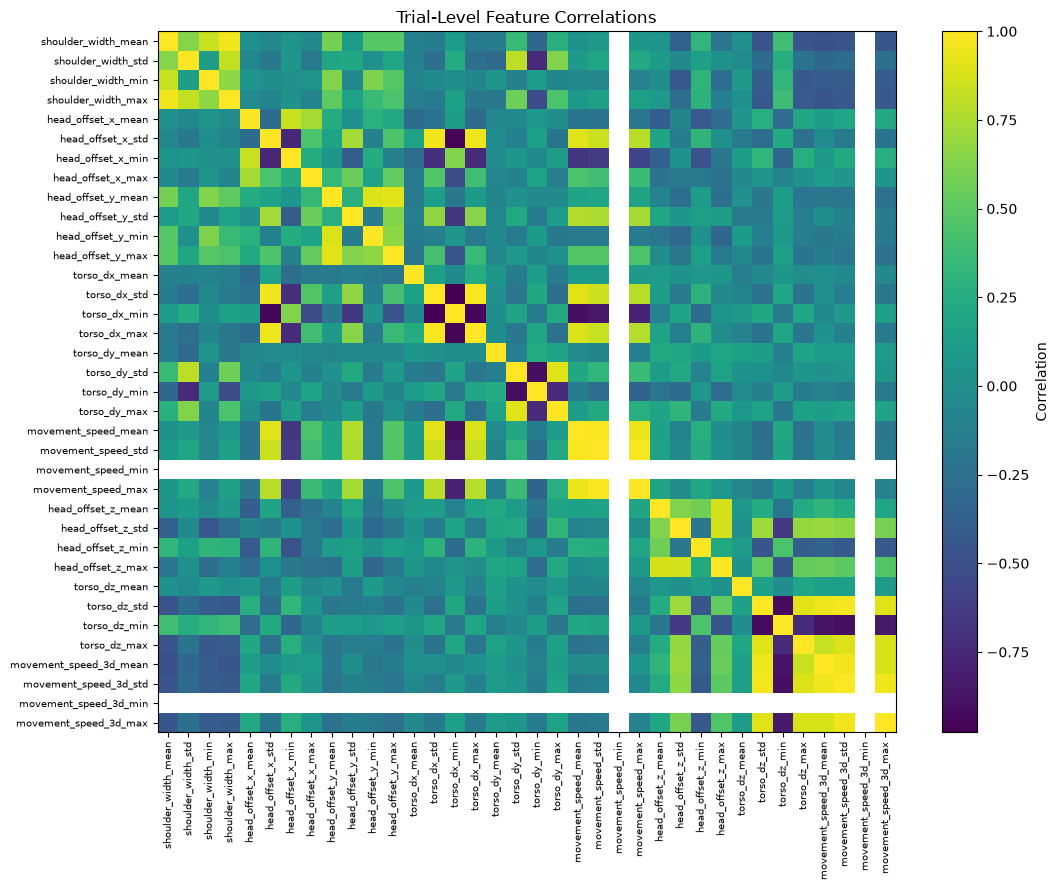

In [45]:
# Trial-level feature relationships

correlation = trial_features[
    trial_feature_columns
].corr()

plt.figure(figsize=(11, 9))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.xticks(
    range(len(trial_feature_columns)),
    trial_feature_columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(trial_feature_columns)),
    trial_feature_columns,
    fontsize=7
)

plt.colorbar(label="Correlation")
plt.title("Trial-Level Feature Correlations")
plt.tight_layout()
plt.show()

In [46]:
# Participant evaluation 

# The evaluation uses leave-one-participant-out splitting.
# For each participant:
# 1. all trials from the other participant are used for training
# 2. all trials from the held-out participant are used for testing.
# No test-participant observations are used during model fitting.

participants = sorted(
    trial_features["participant_id"].unique()
)

print("Participants:")

for participant in participants:
    print(f"  - {participant}")

Participants:
  - P01
  - P02


In [47]:
# Baseline Model
# A Logistic Regression classifier is used as the first baseline.

def create_logistic_model():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42,
                ),
            ),
        ]
    )

In [48]:
# Leave-One-Participant-Out evaluation

results = []
confusion_matrices = {}

X = trial_features[trial_feature_columns]
y = trial_features[TARGET_COLUMN]

for participant in participants:

    train_mask = (
        trial_features["participant_id"] != participant
    )

    test_mask = (
        trial_features["participant_id"] == participant
    )

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    model = create_logistic_model()

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(
        X_test
    )

    results.append(
        {
            "test_participant": participant,
            "train_trials": len(X_train),
            "test_trials": len(X_test),
            "accuracy": accuracy_score(
                y_test,
                predictions,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_test,
                predictions,
            ),
            "macro_f1": f1_score(
                y_test,
                predictions,
                average="macro",
            ),
        }
    )

    confusion_matrices[participant] = confusion_matrix(
        y_test,
        predictions,
        labels=model.classes_,
    )

results_df = pd.DataFrame(results)

display(
    results_df.round(3)
)

,test_participant,train_trials,test_trials,accuracy,balanced_accuracy,macro_f1
0,P01,50,50,0.86,0.86,0.867
1,P02,50,50,0.92,0.92,0.921


In [49]:
# Dummy baseline

dummy_results = []

for participant in participants:

    train_mask = (
        trial_features["participant_id"] != participant
    )

    test_mask = (
        trial_features["participant_id"] == participant
    )

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    dummy = DummyClassifier(
        strategy="most_frequent"
    )

    dummy.fit(
        X_train,
        y_train,
    )

    dummy_predictions = dummy.predict(
        X_test
    )

    dummy_results.append(
        {
            "test_participant": participant,
            "accuracy": accuracy_score(
                y_test,
                dummy_predictions,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_test,
                dummy_predictions,
            ),
            "macro_f1": f1_score(
                y_test,
                dummy_predictions,
                average="macro",
                zero_division=0,
            ),
        }
    )

dummy_results_df = pd.DataFrame(
    dummy_results
)

display(
    dummy_results_df.round(3)
)

,test_participant,accuracy,balanced_accuracy,macro_f1
0,P01,0.2,0.2,0.067
1,P02,0.2,0.2,0.067


In [50]:
# Compare baseline with dummy classifier

comparison = pd.DataFrame(
    {
        "Logistic Regression": [
            results_df["accuracy"].mean(),
            results_df["balanced_accuracy"].mean(),
            results_df["macro_f1"].mean(),
        ],
        "Dummy": [
            dummy_results_df["accuracy"].mean(),
            dummy_results_df["balanced_accuracy"].mean(),
            dummy_results_df["macro_f1"].mean(),
        ],
    },
    index=[
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
    ],
)

comparison_display = comparison.round(3)
display(comparison_display)

,Logistic Regression,Dummy
Accuracy,0.890,0.200
Balanced Accuracy,0.890,0.200
Macro F1,0.894,0.067


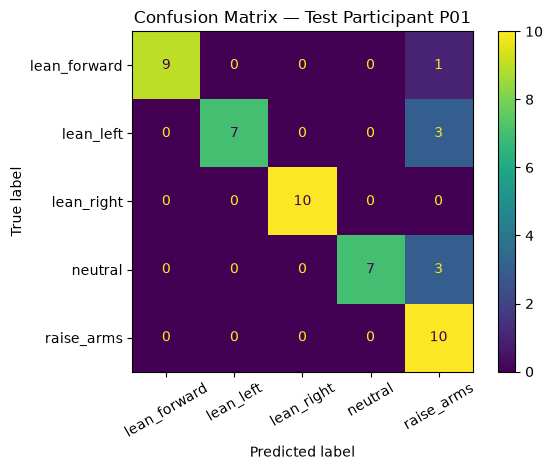

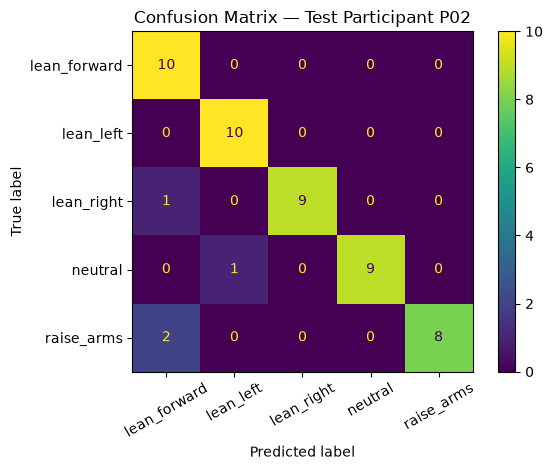

In [51]:
# Confusion matrices

for participant in participants:

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrices[participant],
        display_labels=model.classes_,
    ).plot(
        xticks_rotation=30
    )

    plt.title(
        f"Confusion Matrix — Test Participant {participant}"
    )

    plt.tight_layout()
    plt.show()

In [52]:
# Class-level results

class_results = []

for participant in participants:

    train_mask = (
        trial_features["participant_id"] != participant
    )

    test_mask = (
        trial_features["participant_id"] == participant
    )

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    class_model = create_logistic_model()

    class_model.fit(
        X_train,
        y_train,
    )

    predictions = class_model.predict(
        X_test
    )

    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0,
    )

    for movement in class_model.classes_:

        class_results.append(
            {
                "test_participant": participant,
                "movement": movement,
                "precision": report[movement]["precision"],
                "recall": report[movement]["recall"],
                "f1": report[movement]["f1-score"],
            }
        )

class_results_df = pd.DataFrame(
    class_results
)

display(
    class_results_df.round(3)
)

,test_participant,movement,precision,recall,f1
0,P01,lean_forward,1.000,0.9,0.947
1,P01,lean_left,1.000,0.7,0.824
2,P01,lean_right,1.000,1.0,1.000
3,P01,neutral,1.000,0.7,0.824
4,P01,raise_arms,0.588,1.0,0.741
5,P02,lean_forward,0.769,1.0,0.870
6,P02,lean_left,0.909,1.0,0.952
7,P02,lean_right,1.000,0.9,0.947
8,P02,neutral,1.000,0.9,0.947
9,P02,raise_arms,1.000,0.8,0.889


In [53]:
# Feature ablation 

# The full representation uses four summary statistics per feature:
# mean, std, min, and max.
# To test whether the baseline depends on the more redundant statistics,
# a reduced representation using only mean and std is evaluated.

REDUCED_STATISTICS = [
    "mean",
    "std",
]

reduced_feature_columns = [
    f"{feature}_{stat}"
    for feature in FEATURE_COLUMNS
    for stat in REDUCED_STATISTICS
]

print(
    f"Full representation: "
    f"{len(trial_feature_columns)} features"
)

print(
    f"Reduced representation: "
    f"{len(reduced_feature_columns)} features"
)

Full representation: 36 features
Reduced representation: 18 features


In [54]:
ablation_results = []

for participant in participants:

    train_mask = (
        trial_features["participant_id"] != participant
    )

    test_mask = (
        trial_features["participant_id"] == participant
    )

    X_train = trial_features.loc[
        train_mask,
        reduced_feature_columns,
    ]

    X_test = trial_features.loc[
        test_mask,
        reduced_feature_columns,
    ]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    ablation_model = create_logistic_model()

    ablation_model.fit(
        X_train,
        y_train,
    )

    predictions = ablation_model.predict(
        X_test
    )

    ablation_results.append(
        {
            "test_participant": participant,
            "features": len(reduced_feature_columns),
            "accuracy": accuracy_score(
                y_test,
                predictions,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_test,
                predictions,
            ),
            "macro_f1": f1_score(
                y_test,
                predictions,
                average="macro",
            ),
        }
    )

ablation_results_df = pd.DataFrame(
    ablation_results
)

display(
    ablation_results_df.round(3)
)

,test_participant,features,accuracy,balanced_accuracy,macro_f1
0,P01,18,0.88,0.88,0.878
1,P02,18,0.96,0.96,0.960


In [55]:
# Compare full and reduced representations

full_mean = results_df[
    [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ]
].mean()

reduced_mean = ablation_results_df[
    [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ]
].mean()

ablation_comparison = pd.DataFrame(
    {
        "Full (36 features)": full_mean,
        "Reduced (18 features)": reduced_mean,
        "Difference": reduced_mean - full_mean,
    }
)

display(
    ablation_comparison.round(3)
)

,Full (36 features),Reduced (18 features),Difference
accuracy,0.890,0.920,0.030
balanced_accuracy,0.890,0.920,0.030
macro_f1,0.894,0.919,0.025


## Interpretation

The baseline results show that the aggregated pose-based movement representation contains information useful for distinguishing between the five movement classes when evaluated on a held-out participant.

The Logistic Regression baseline achieves a mean balanced accuracy of 0.890, compared with 0.200 for the most-frequent dummy classifier. This indicates that the learned representation provides substantially more discriminative information than the trivial reference.

Performance differs between the two held-out participants. These differences may reflect variation in movement style, body proportions, camera position, or recording conditions.

### Feature Ablation

The feature ablation provides an additional result. A reduced representation using only mean and standard deviation (18 features) achieves a mean balanced accuracy of 0.920, compared with 0.890 for the full 36-feature representation.

The additional minimum and maximum statistics therefore did not improve performance in this dataset. The reduced representation provides a simpler alternative with fewer features and slightly better cross-participant performance.

This result is exploratory because only two participants are available. It does not establish that the reduced representation will consistently outperform the full representation on a larger population.

## Limitations

This baseline experiment has several limitations:

- only two participants are available
- the dataset contains 100 trials in total
- each participant contributes only two sessions
- trial-level aggregation removes some temporal structure
- participant and recording session are linked in the current evaluation, so holding out a participant also holds out all of that participant's sessions
- the small training set limits the stability of performance estimates

The results should therefore be interpreted as an exploratory evaluation of the movement representation rather than evidence of generalisation to a broader population.

## Next Step: Personalised Modelling

The next experiment will investigate whether a small amount of participant-specific calibration data improves classification performance on unseen trials from the target participant.

The same evaluation framework and Logistic Regression model will be used so that the effect of personalisation can be evaluated independently of changes in the classifier.

The personalised experiment will evaluate both feature representations: the original 36-feature representation and the reduced 18-feature representation identified through the ablation experiment. This will allow the effect of personalisation to be assessed separately from the choice of feature representation.